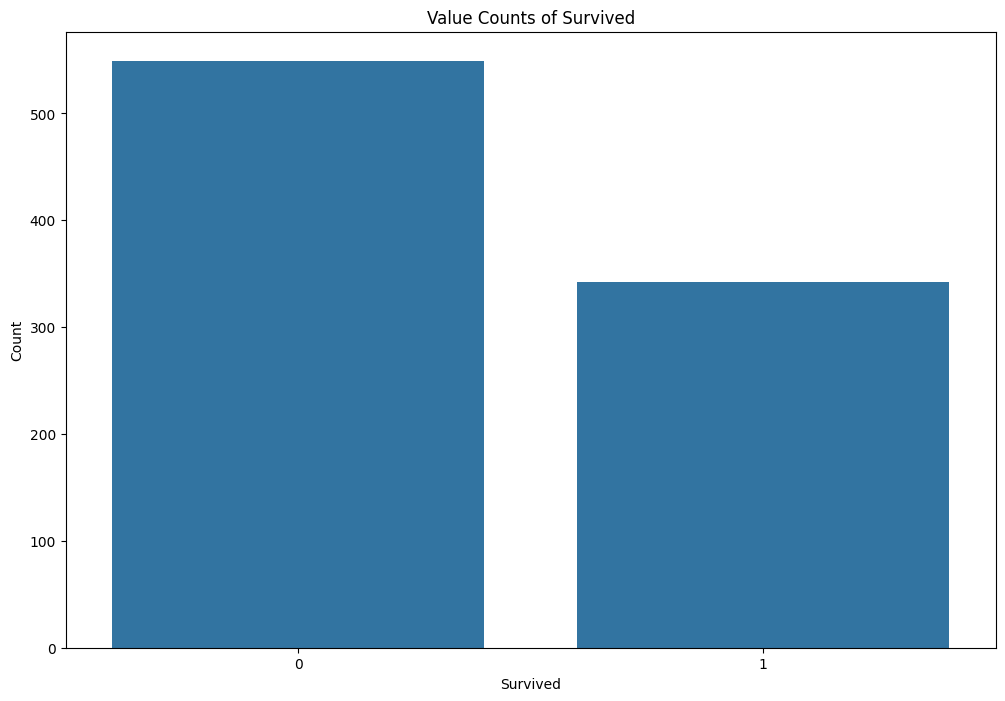

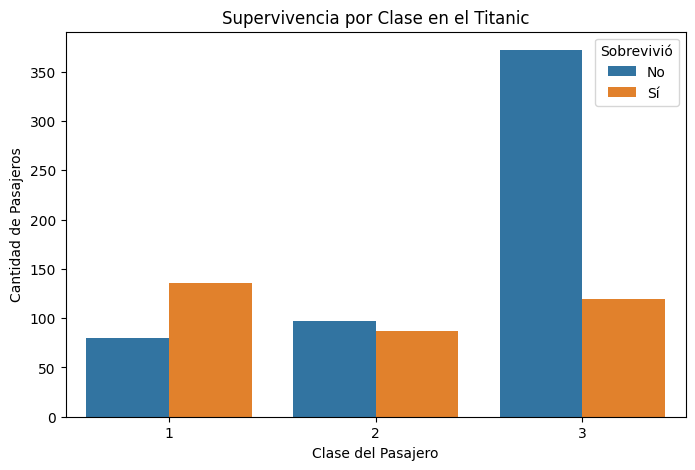

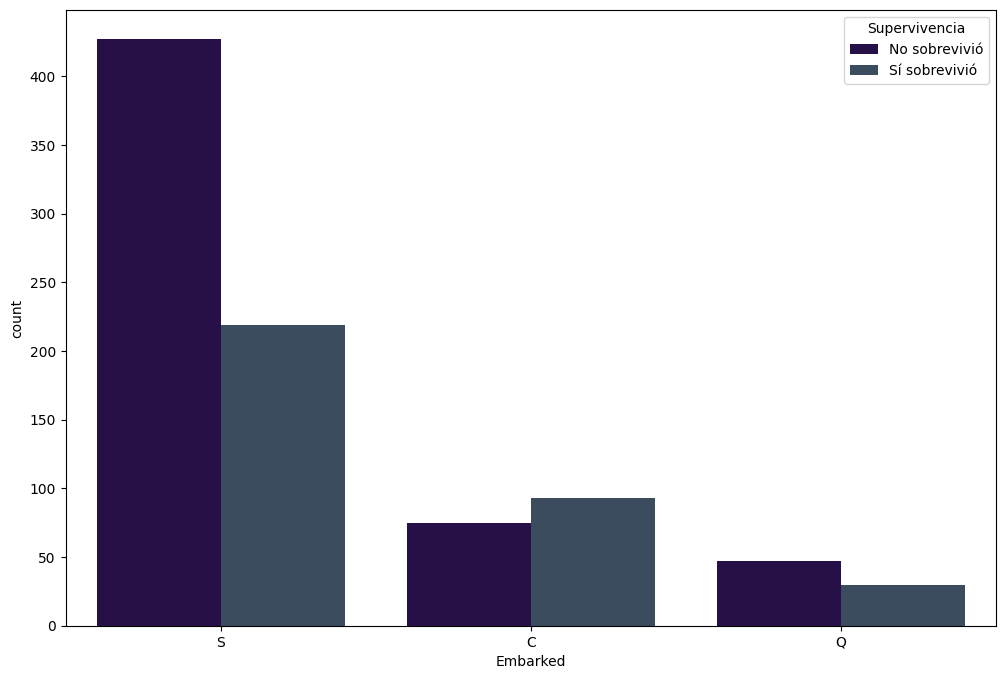

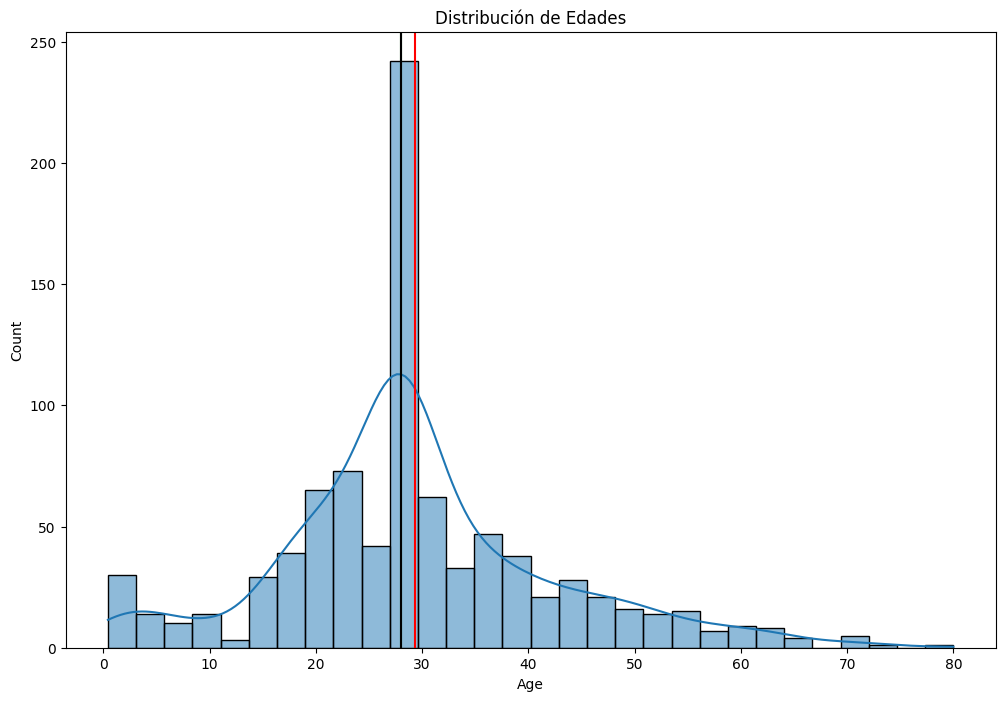

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


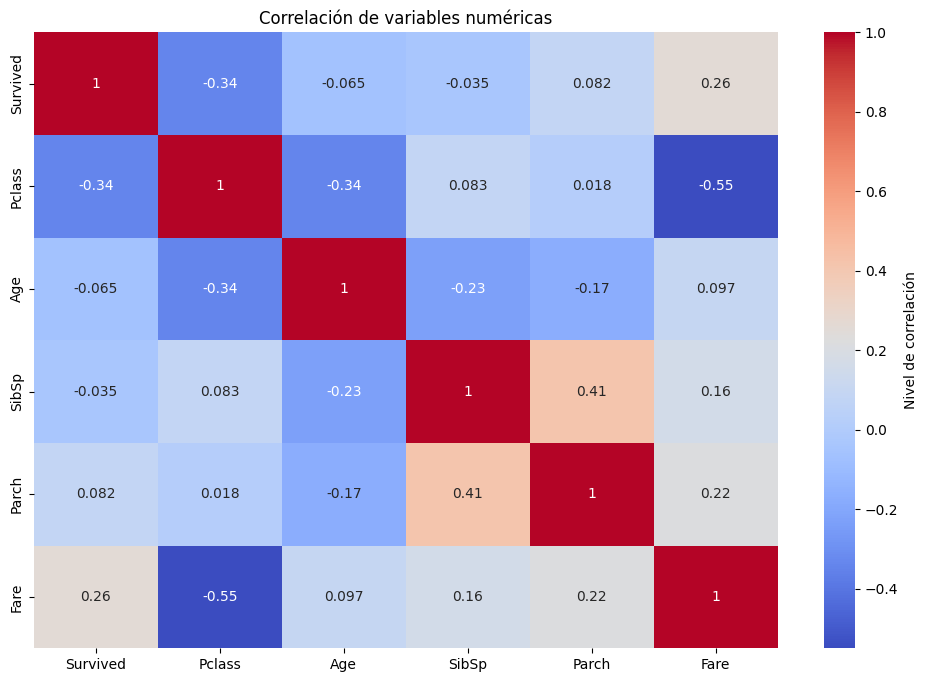

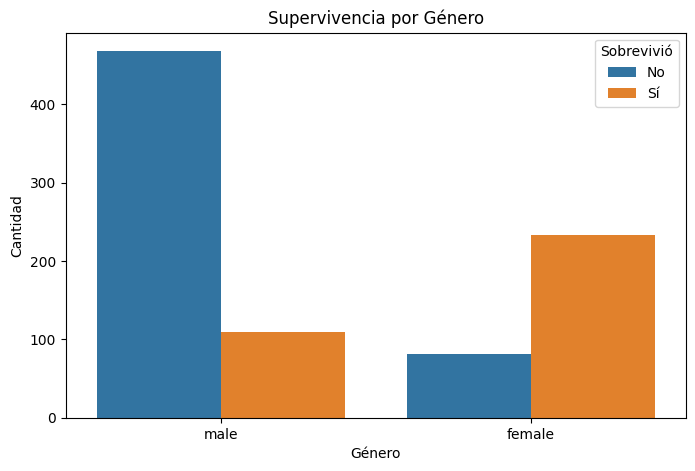

C:\Users\sebas\AppData\Local\Temp\ipykernel_11680\83279066.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = df.dropna(subset=['Age']).groupby('AgeGroup')['Survived'].mean().mul(100).reindex(labels)


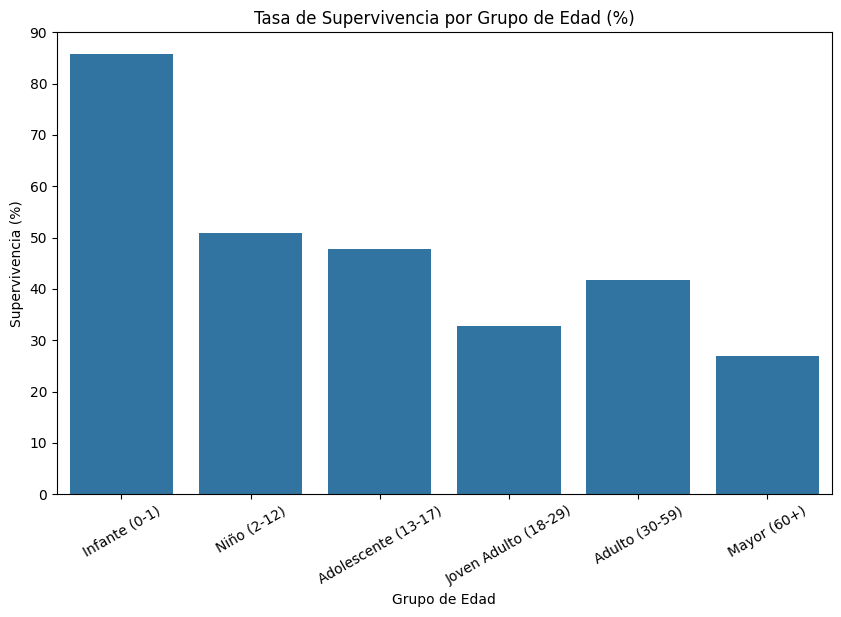

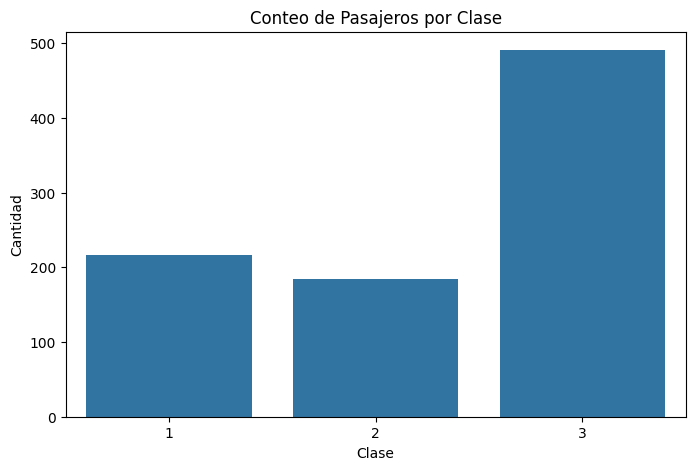

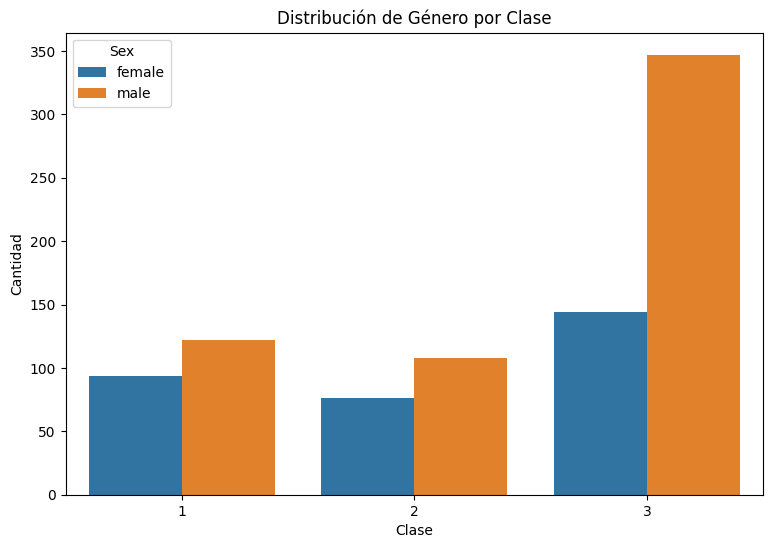

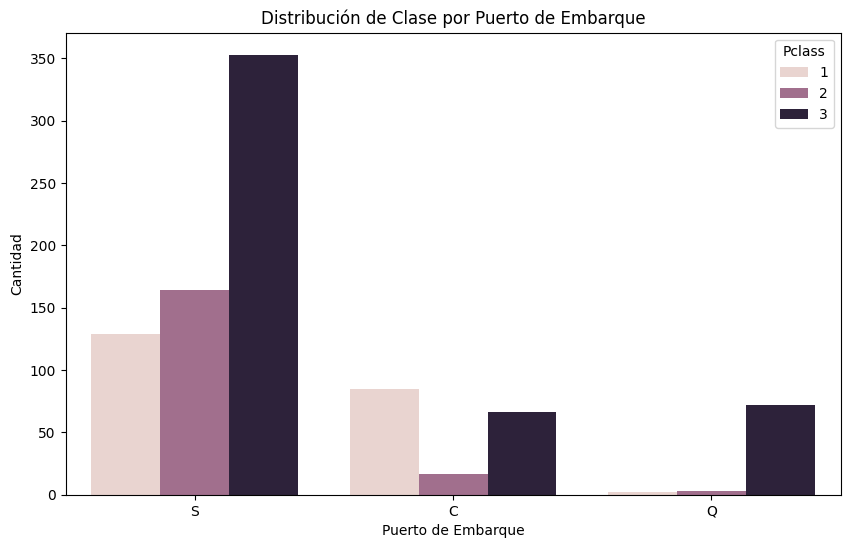

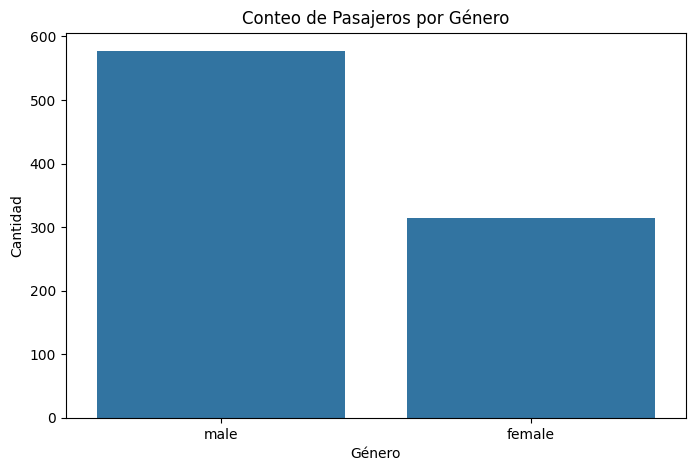

Edad mínima: 0.42
Edad máxima: 80.0


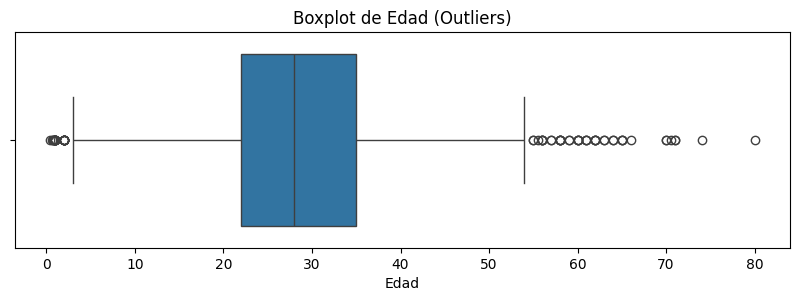

Tarifa mínima (Fare): 0.0
Tarifa máxima (Fare): 512.3292


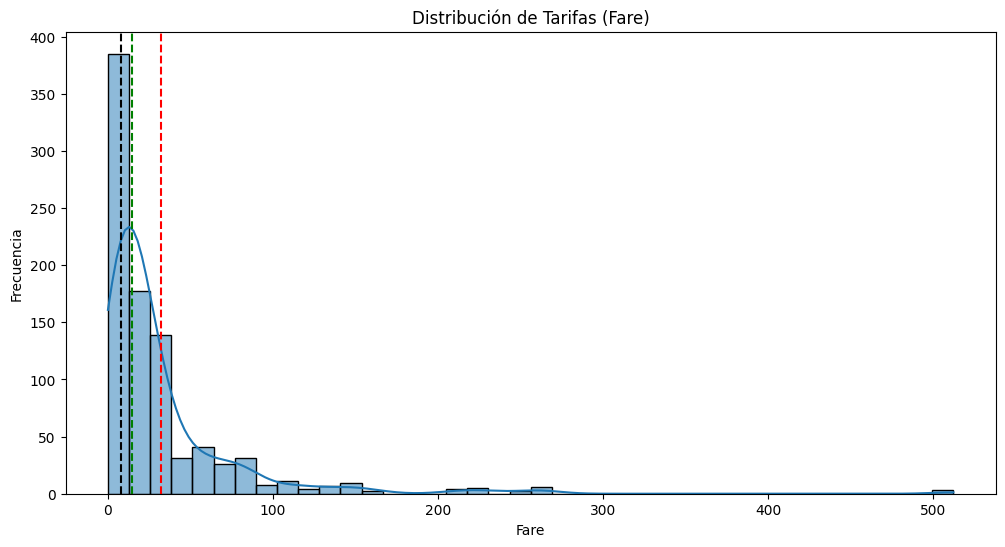

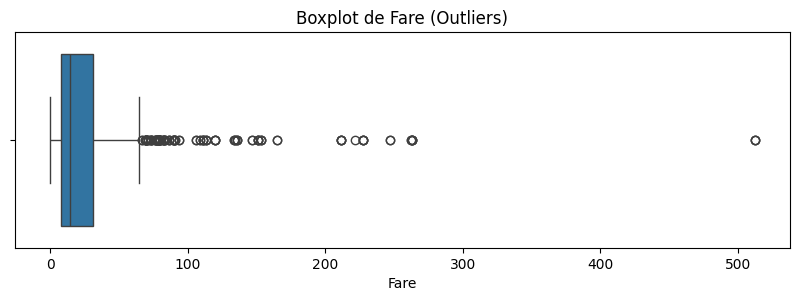

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
179,0,3,male,36.0,0,0,0.0,S,Adulto (30-59)
263,0,1,male,40.0,0,0,0.0,S,Adulto (30-59)
271,1,3,male,25.0,0,0,0.0,S,Joven Adulto (18-29)
277,0,2,male,28.0,0,0,0.0,S,Joven Adulto (18-29)
302,0,3,male,19.0,0,0,0.0,S,Joven Adulto (18-29)
413,0,2,male,28.0,0,0,0.0,S,Joven Adulto (18-29)
466,0,2,male,28.0,0,0,0.0,S,Joven Adulto (18-29)
481,0,2,male,28.0,0,0,0.0,S,Joven Adulto (18-29)
597,0,3,male,49.0,0,0,0.0,S,Adulto (30-59)
633,0,1,male,28.0,0,0,0.0,S,Joven Adulto (18-29)


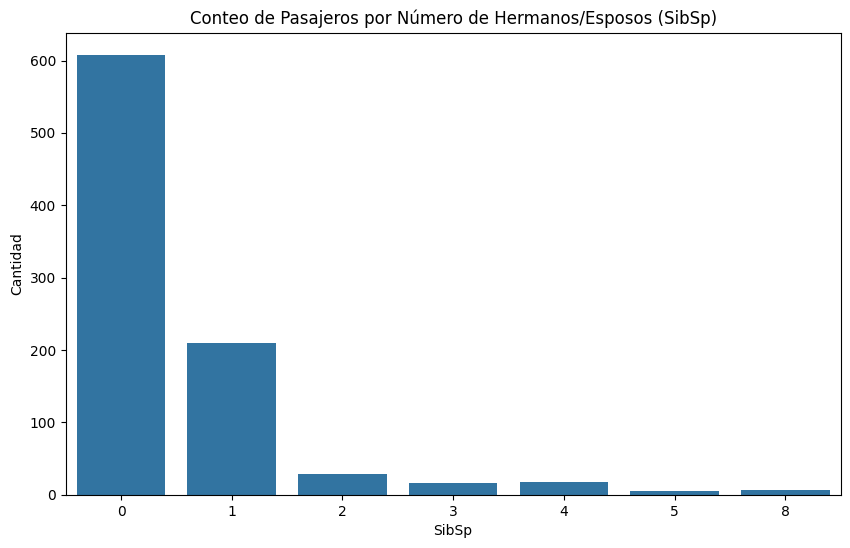

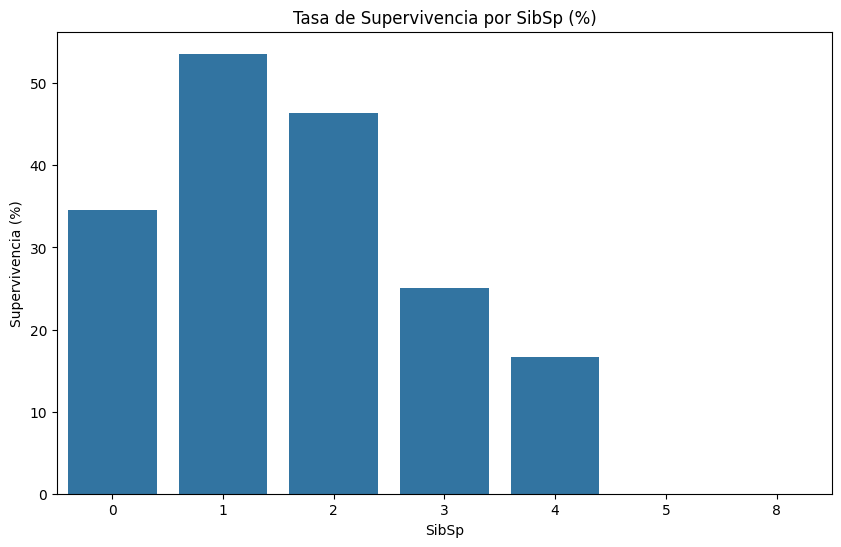

,Total,Sobrevivientes,Supervivencia_%
SibSp,,,
0,608,210,34.54
1,209,112,53.59
2,28,13,46.43
3,16,4,25.00
4,18,3,16.67
5,5,0,0.00
8,7,0,0.00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/titanic_clean.csv')

df.sample(4)

df['Survived'].value_counts()

plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Asumiendo que el DataFrame se llama df
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Supervivencia por Clase en el Titanic')
plt.xlabel('Clase del Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.show()

plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Supervivencia por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.show()

bins = [0, 2, 13, 18, 30, 60, np.inf]
labels = ['Infante (0-1)', 'Niño (2-12)', 'Adolescente (13-17)', 'Joven Adulto (18-29)', 'Adulto (30-59)', 'Mayor (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
survival_by_agegroup = df.dropna(subset=['Age']).groupby('AgeGroup')['Survived'].mean().mul(100).reindex(labels)

plt.figure(figsize=(10,6))
sns.barplot(x=survival_by_agegroup.index, y=survival_by_agegroup.values)
plt.title('Tasa de Supervivencia por Grupo de Edad (%)')
plt.xlabel('Grupo de Edad')
plt.ylabel('Supervivencia (%)')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Pclass', order=[1,2,3])
plt.title('Conteo de Pasajeros por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

plt.figure(figsize=(9,6))
sns.countplot(data=df, x='Pclass', hue='Sex', order=[1,2,3])
sns.move_legend, plt.title('Distribución de Género por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Embarked', hue='Pclass', hue_order=[1,2,3])
plt.title('Distribución de Clase por Puerto de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Cantidad')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sex')
plt.title('Conteo de Pasajeros por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()

age_min = df['Age'].min(skipna=True)
age_max = df['Age'].max(skipna=True)
print(f"Edad mínima: {age_min}")
print(f"Edad máxima: {age_max}")

plt.figure(figsize=(10,2.8))
sns.boxplot(x=df['Age'])
plt.title('Boxplot de Edad (Outliers)')
plt.xlabel('Edad')
plt.show()

fare_min = df['Fare'].min(skipna=True)
fare_max = df['Fare'].max(skipna=True)
print(f"Tarifa mínima (Fare): {fare_min}")
print(f"Tarifa máxima (Fare): {fare_max}")

plt.figure(figsize=(12,6))
sns.histplot(df, x='Fare', bins=40, kde=True)
plt.title('Distribución de Tarifas (Fare)')
plt.xlabel('Fare')
plt.ylabel('Frecuencia')
plt.axvline(df['Fare'].mean(), color='red', linestyle='--')
plt.axvline(df['Fare'].median(), color='green', linestyle='--')
plt.axvline(df['Fare'].mode(dropna=True)[0], color='black', linestyle='--')
plt.show()

plt.figure(figsize=(10,2.8))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot de Fare (Outliers)')
plt.xlabel('Fare')
plt.show()

free_fare = df[df['Fare'] == 0]
display(free_fare.head(20))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='SibSp')
plt.title('Conteo de Pasajeros por Número de Hermanos/Esposos (SibSp)')
plt.xlabel('SibSp')
plt.ylabel('Cantidad')
plt.show()

survival_by_sibsp = df.groupby('SibSp')['Survived'].mean().mul(100)
plt.figure(figsize=(10,6))
sns.barplot(x=survival_by_sibsp.index, y=survival_by_sibsp.values)
plt.title('Tasa de Supervivencia por SibSp (%)')
plt.xlabel('SibSp')
plt.ylabel('Supervivencia (%)')
plt.show()

survival_pct_table = df.groupby('SibSp')['Survived'].agg(['count','sum']).rename(columns={'count':'Total','sum':'Sobrevivientes'})
survival_pct_table['Supervivencia_%'] = (survival_pct_table['Sobrevivientes'] / survival_pct_table['Total'] * 100).round(2)
display(survival_pct_table.sort_index())


